In [10]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold, train_test_split
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from deepface import DeepFace
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import gc

In [2]:
DATA_DIR = r"C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\data\imgData\prepImg\step4"
SEED = 123
all_paths = []
all_labels = []
class_names = ['Autistic', 'Non_Autistic']

IMG_SIZE = (224, 224)
BATCH_SIZE = 8          
SEED = 123
fold_no = 1              
fold_results = []        
num_folds = 5

methana idn oni na aith

In [3]:
for class_idx, class_name in enumerate(class_names):
    class_folder = os.path.join(DATA_DIR, class_name)
    for img_name in os.listdir(class_folder):
        all_paths.append(os.path.join(class_folder, img_name))
        # Logic: Autistic is class_idx 0. 
        # We will apply (1 - y) later in the pipeline to make Autistic = 1
        all_labels.append(class_idx)

In [4]:
all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

In [5]:
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.10, random_state=SEED, stratify=all_labels
)

In [6]:
print(f"Permanent Test Set isolated: {len(test_paths)} images.")
print(f"Data remaining for K-Fold: {len(train_val_paths)} images.")

Permanent Test Set isolated: 392 images.
Data remaining for K-Fold: 3525 images.


In [7]:
# --- 4. Define K-Fold ---
num_folds = 5
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=SEED)

fold_no = 1
# This list will store the reliability metrics for each fold
fold_results = []


In [12]:
FOLDS_DIR = r"C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\data\imgData\prepImg\Folds"
if not os.path.exists(FOLDS_DIR):
    os.makedirs(FOLDS_DIR)
    print(f"Created directory: {FOLDS_DIR}")

splits = list(kfold.split(train_val_paths, train_val_labels))

for i, (train_index, val_index) in enumerate(splits):
    fold_id = i + 1
    
    # Extract the paths and labels for this specific fold
    train_paths = train_val_paths[train_index]
    train_labels = train_val_labels[train_index]
    val_paths = train_val_paths[val_index]
    val_labels = train_val_labels[val_index]
    
    # Save to disk
    np.save(os.path.join(FOLDS_DIR, f'fold_{fold_id}_train_paths.npy'), train_paths)
    np.save(os.path.join(FOLDS_DIR, f'fold_{fold_id}_train_labels.npy'), train_labels)
    np.save(os.path.join(FOLDS_DIR, f'fold_{fold_id}_val_paths.npy'), val_paths)
    np.save(os.path.join(FOLDS_DIR, f'fold_{fold_id}_val_labels.npy'), val_labels)
    
    print(f"Fold {fold_id} saved: {len(train_paths)} train, {len(val_paths)} val images.")

print("\nAll folds are successfully locked to the hard drive.")

Created directory: C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\data\imgData\prepImg\Folds
Fold 1 saved: 2820 train, 705 val images.
Fold 2 saved: 2820 train, 705 val images.
Fold 3 saved: 2820 train, 705 val images.
Fold 4 saved: 2820 train, 705 val images.
Fold 5 saved: 2820 train, 705 val images.

All folds are successfully locked to the hard drive.


Oni na me kalla

In [ ]:
FOLDS_DIR = r"C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\data\imgData\prepImg\Folds"
CURRENT_FOLD = 1
train_paths_fold = np.load(os.path.join(FOLDS_DIR, f'fold_{CURRENT_FOLD}_train_paths.npy'), allow_pickle=True)
train_labels_fold = np.load(os.path.join(FOLDS_DIR, f'fold_{CURRENT_FOLD}_train_labels.npy'), allow_pickle=True)
val_paths_fold = np.load(os.path.join(FOLDS_DIR, f'fold_{CURRENT_FOLD}_val_paths.npy'), allow_pickle=True)
val_labels_fold = np.load(os.path.join(FOLDS_DIR, f'fold_{CURRENT_FOLD}_val_labels.npy'), allow_pickle=True)
print(f"--- FOLD {CURRENT_FOLD} LOADED ---")
print(f"Training images: {len(train_paths_fold)}")
print(f"Validation images: {len(val_paths_fold)}")

In [ ]:
# --- 3. DATA PIPELINE ---
data_augmentation_layers = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03), 
    tf.keras.layers.RandomContrast(0.1),
])

def process_fold_data(file_path, label, augment=False):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    
    # VGG-Face Preprocessing: BGR conversion and Mean Subtraction
    img = img[..., ::-1] # RGB to BGR
    mean = [93.5940, 104.7624, 129.1863]
    img = img - mean

    if augment:
        img = tf.expand_dims(img, 0)
        img = data_augmentation_layers(img, training=True)
        img = tf.squeeze(img, 0)

    # Class logic: Maps to Autistic=1, Non_Autistic=0
    target_label = 1.0 - tf.cast(label, tf.float32)
    return img, {
        'classification_output': target_label, 
        'asd_feature_vector': target_label
    }

train_ds_fold = (tf.data.Dataset.from_tensor_slices((train_paths_fold, train_labels_fold))
                 .shuffle(len(train_paths_fold))
                 .map(lambda x, y: process_fold_data(x, y, augment=True), num_parallel_calls=tf.data.AUTOTUNE)
                 .batch(BATCH_SIZE)
                 .prefetch(tf.data.AUTOTUNE))

val_ds_fold = (tf.data.Dataset.from_tensor_slices((val_paths_fold, val_labels_fold))
               .map(lambda x, y: process_fold_data(x, y, augment=False), num_parallel_calls=tf.data.AUTOTUNE)
               .batch(BATCH_SIZE)
               .prefetch(tf.data.AUTOTUNE))

# --- 4. MODEL ARCHITECTURE ---
vgg_model_wrapper = DeepFace.build_model("VGG-Face")
full_vgg_face = vgg_model_wrapper.model 
backbone_output = full_vgg_face.get_layer("conv2d_14").output
feature_extractor = Model(inputs=full_vgg_face.input, outputs=backbone_output)
feature_extractor.trainable = False 

inputs = Input(shape=(224, 224, 3), name="face_input")
x = feature_extractor(inputs, training=False)
x = GlobalAveragePooling2D()(x)
feature_layer = Dense(256, activation='relu', kernel_regularizer=l2(0.01), name='asd_feature_vector')(x)
x = Dropout(0.5)(feature_layer)
prediction = Dense(1, activation='sigmoid', name='classification_output')(x)

unified_model = Model(inputs=inputs, outputs=[prediction, feature_layer])

# --- 5. TRAINING PHASE 1 (FROZEN) ---
lr_scheduler = ReduceLROnPlateau(monitor='val_classification_output_loss', factor=0.5, patience=3, verbose=1)
early_stop = EarlyStopping(monitor='val_classification_output_loss', patience=8, restore_best_weights=True)
checkpoint = ModelCheckpoint(f'fold_{CURRENT_FOLD}_best.h5', monitor='val_classification_output_accuracy', save_best_only=True, mode='max', verbose=1)

unified_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss={'classification_output': 'binary_crossentropy', 'asd_feature_vector': None},
    metrics={'classification_output': ['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]}
)

print("\nStarting Phase 1 (Frozen Backbone)...")
unified_model.fit(train_ds_fold, validation_data=val_ds_fold, epochs=30, callbacks=[lr_scheduler, early_stop, checkpoint])

# --- 6. TRAINING PHASE 2 (FINE-TUNING) ---
feature_extractor.trainable = True
for layer in feature_extractor.layers[:-12]:
    layer.trainable = False

# Re-compile is required after changing trainable status
unified_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-6, weight_decay=1e-4),
    loss={'classification_output': 'binary_crossentropy', 'asd_feature_vector': None},
    metrics={'classification_output': ['accuracy']}
)

print("\nStarting Phase 2 (Fine-Tuning Last 12 Layers)...")
history_p2 = unified_model.fit(train_ds_fold, validation_data=val_ds_fold, epochs=15, callbacks=[lr_scheduler, early_stop, checkpoint])

# --- 7. FINAL LOGGING ---
final_acc = max(history_p2.history['val_classification_output_accuracy'])
print(f"\nFINISHED FOLD {CURRENT_FOLD}")
print(f"Peak Validation Accuracy: {final_acc:.4f}")

In [8]:
# This ensures we build the exact same architecture every time we reset memory
def create_unified_model():
    vgg_model_wrapper = DeepFace.build_model("VGG-Face")
    full_vgg_face = vgg_model_wrapper.model 
    backbone_output = full_vgg_face.get_layer("conv2d_14").output
    feature_extractor = Model(inputs=full_vgg_face.input, outputs=backbone_output)
    feature_extractor.trainable = False 

    inputs = Input(shape=(224, 224, 3), name="face_input")
    x = feature_extractor(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    feature_layer = Dense(256, activation='relu', kernel_regularizer=l2(0.01), name='asd_feature_vector')(x)
    x = Dropout(0.5)(feature_layer)
    prediction = Dense(1, activation='sigmoid', name='classification_output')(x)

    model = Model(inputs=inputs, outputs=[prediction, feature_layer])
    return model, feature_extractor

In [11]:
# --- 5. The Reliability Loop ---
for train_index, val_index in kfold.split(train_val_paths, train_val_labels):
    print(f"\n" + "="*40)
    print(f"--- STARTING FOLD {fold_no} ---")
    print("="*40)
    
    # 1. Dataset Preparation
    train_paths_fold = train_val_paths[train_index]
    train_labels_fold = train_val_labels[train_index]
    val_paths_fold = train_val_paths[val_index]
    val_labels_fold = train_val_labels[val_index]

    # 2. Define Augmentation
    data_augmentation_layers = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.03), 
        tf.keras.layers.RandomContrast(0.1),
    ])

    # 3. Preprocessing Function (CORRECTED: VGG-Face Mean Subtraction)
    def process_fold_data(file_path, label, augment=False):
        img = tf.io.read_file(file_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [224, 224])
        
        # VGG-Face expects BGR and Mean Subtraction. 
        # This is a standard implementation for VGG-based models:
        img = img[..., ::-1] # RGB to BGR
        mean = [93.5940, 104.7624, 129.1863] # VGG-Face specific means
        img = img - mean

        if augment:
            img = tf.expand_dims(img, 0)
            img = data_augmentation_layers(img, training=True)
            img = tf.squeeze(img, 0)

        target_label = 1.0 - tf.cast(label, tf.float32)
        return img, {
            'classification_output': target_label, 
            'asd_feature_vector': target_label
        }

    # 4. Build Datasets
    train_ds_fold = (tf.data.Dataset.from_tensor_slices((train_paths_fold, train_labels_fold))
                     .shuffle(len(train_paths_fold))
                     .map(lambda x, y: process_fold_data(x, y, augment=True), 
                          num_parallel_calls=tf.data.AUTOTUNE)
                     .batch(BATCH_SIZE)
                     .prefetch(tf.data.AUTOTUNE))

    val_ds_fold = (tf.data.Dataset.from_tensor_slices((val_paths_fold, val_labels_fold))
                   .map(lambda x, y: process_fold_data(x, y, augment=False), 
                        num_parallel_calls=tf.data.AUTOTUNE)
                   .batch(BATCH_SIZE)
                   .prefetch(tf.data.AUTOTUNE))

    # 5. Callbacks & Loss Config
    fold_checkpoint = f'fold_{fold_no}_best.h5'
    loss_config = {'classification_output': 'binary_crossentropy', 'asd_feature_vector': None}
    
    checkpoint_callback = ModelCheckpoint(
        fold_checkpoint, monitor='val_classification_output_accuracy', 
        save_best_only=True, mode='max', verbose=1
    )
    lr_scheduler = ReduceLROnPlateau(monitor='val_classification_output_loss', factor=0.5, patience=3, verbose=1)
    early_stop = EarlyStopping(monitor='val_classification_output_loss', patience=8, restore_best_weights=True)

    # --- PHASE 1: Frozen Training ---
    print(f"Building Model for Fold {fold_no} Phase 1...")
    unified_model, feature_extractor = create_unified_model()
    
    unified_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss=loss_config,
        metrics={'classification_output': ['accuracy']}
    )

    unified_model.fit(train_ds_fold, validation_data=val_ds_fold, epochs=30, callbacks=[lr_scheduler, early_stop, checkpoint_callback])

    # --- THE "DEEP CLEAN" RESET ---
    print(f"\nResetting GPU memory for Phase 2...")
    del unified_model
    del feature_extractor
    tf.keras.backend.clear_session()
    gc.collect()

    # --- PHASE 2: Fine-Tuning ---
    unified_model, feature_extractor = create_unified_model()
    unified_model.load_weights(fold_checkpoint) 

    # Unfreeze the last 12 layers
    feature_extractor.trainable = True
    for layer in feature_extractor.layers[:-12]:
        layer.trainable = False

    # RE-COMPILE is mandatory after changing trainable status
    unified_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
        loss=loss_config,
        metrics={'classification_output': ['accuracy']}
    )

    print(f"Starting Phase 2 (Fine-Tuning) for Fold {fold_no}...")
    history_p2 = unified_model.fit(train_ds_fold, validation_data=val_ds_fold, epochs=15, callbacks=[lr_scheduler, early_stop, checkpoint_callback])

    # 6. Final Results & Cleanup
    final_val_acc = max(history_p2.history['val_classification_output_accuracy'])
    fold_results.append(final_val_acc)
    
    del train_ds_fold
    del val_ds_fold
    del unified_model
    del feature_extractor
    tf.keras.backend.clear_session()
    gc.collect() 
    
    fold_no += 1


--- STARTING FOLD 1 ---
Building Model for Fold 1 Phase 1...
Epoch 1/30
353/353 [==============================] - ETA: 0s - loss: 4.4820 - classification_output_loss: 0.8838 - classification_output_accuracy: 0.6330
Epoch 1: val_classification_output_accuracy improved from -inf to 0.66667, saving model to fold_1_best.h5
353/353 [==============================] - 55s 153ms/step - loss: 4.4820 - classification_output_loss: 0.8838 - classification_output_accuracy: 0.6330 - val_loss: 3.8404 - val_classification_output_loss: 0.7774 - val_classification_output_accuracy: 0.6667 - lr: 1.0000e-04
Epoch 2/30
353/353 [==============================] - ETA: 0s - loss: 3.3007 - classification_output_loss: 0.5090 - classification_output_accuracy: 0.7663
Epoch 2: val_classification_output_accuracy improved from 0.66667 to 0.70355, saving model to fold_1_best.h5
353/353 [==============================] - 65s 185ms/step - loss: 3.3007 - classification_output_loss: 0.5090 - classification_output_accura

KeyboardInterrupt: 

In [8]:
# # --- 2. Build the Unified Model (Phase 2 Architecture) ---

# # Step 4.1: Define Input and attach Augmentation
# inputs = Input(shape=(224, 224, 3), name="face_input")

# # Apply the augmentation layer defined in Phase 1
# # training=True ensures augmentation is active only during training
# x = data_augmentation(inputs) 

# # Pass through the VGG backbone
# x = feature_extractor_base(x, training=False)

# # Step 4.2: Global Pooling (Turning 3D maps into a 1D vector)
# x = GlobalAveragePooling2D()(x)

# # Step 5: Regularization (The 0.5 Dropout Layer)
# # This forces the model to find multiple ASD markers
# x = Dropout(0.5)(x)

# # Step 4.2: Build the Dual-Output Head
# # Output B: Feature Extraction (The 256-D "Fingerprint")
# asd_features = Dense(256, activation='relu', name='asd_feature_vector')(x)

# # Output A: Classification (The Sigmoid Diagnosis)
# # We branch this directly from the feature vector
# classification = Dense(1, activation='sigmoid', name='classification_output')(asd_features)

# # --- 3. Create the Functional Model ---
# unified_model = Model(
#     inputs=inputs, 
#     outputs=[classification, asd_features],
#     name="ASD_DualOutput_Model"
# )

# # --- 4. Verify the Structure ---
# unified_model.summary()

# print("\nPhase 2 Complete: Unified Model with Dual-Output Head created.")
# print("Output 1: 'classification_output' (ASD Probability)")
# print("Output 2: 'asd_feature_vector' (256-D Fingerprint for t-SNE)")

Model: "ASD_DualOutput_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 face_input (InputLayer)     [(None, 224, 224, 3)]     0         
                                                                 
 augmentation_layer (Sequent  (None, 224, 224, 3)      0         
 ial)                                                            
                                                                 
 model_1 (Functional)        (None, 1, 1, 4096)        134260544 
                                                                 
 global_average_pooling2d (G  (None, 4096)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout_2 (Dropout)         (None, 4096)              0         
                                                                 
 asd_feature_vector (Dense)  (None, 256)      

In [18]:
# # --- 5. The Reliability Loop ---
# for train_index, val_index in kfold.split(train_val_paths, train_val_labels):
#     print(f"\n--- STARTING FOLD {fold_no} ---")
    
#     # Split the paths based on K-Fold indices
#     train_paths_fold = train_val_paths[train_index]
#     train_labels_fold = train_val_labels[train_index]
    
#     val_paths_fold = train_val_paths[val_index]
#     val_labels_fold = train_val_labels[val_index]
    
#     # --- 1. Define Augmentation Layer (Stage 2 Addition) ---
#     data_augmentation_layers = tf.keras.Sequential([
#         tf.keras.layers.RandomFlip("horizontal"),
#         tf.keras.layers.RandomRotation(0.03), 
#         tf.keras.layers.RandomContrast(0.1),
#     ])

#     # --- 2. Advanced Preprocessing Function ---
#     def process_fold_data(file_path, label, augment=False):
#         img = tf.io.read_file(file_path)
#         img = tf.image.decode_jpeg(img, channels=3)
#         img = tf.image.resize(img, [224, 224])
#         img = img / 255.0 

#         if augment:
#             img = tf.expand_dims(img, 0)
#             img = data_augmentation_layers(img, training=True)
#             img = tf.squeeze(img, 0)

#         target_label = 1.0 - tf.cast(label, tf.float32)
#         return img, {
#             'classification_output': target_label, 
#             'asd_feature_vector': target_label
#         }

#     # --- 3. Build the Datasets inside the Loop ---
#     train_ds_fold = (tf.data.Dataset.from_tensor_slices((train_paths_fold, train_labels_fold))
#                      .shuffle(len(train_paths_fold))
#                      .map(lambda x, y: process_fold_data(x, y, augment=True), 
#                           num_parallel_calls=tf.data.AUTOTUNE)
#                      .batch(BATCH_SIZE)
#                      .prefetch(tf.data.AUTOTUNE))

#     val_ds_fold = (tf.data.Dataset.from_tensor_slices((val_paths_fold, val_labels_fold))
#                    .map(lambda x, y: process_fold_data(x, y, augment=False), 
#                         num_parallel_calls=tf.data.AUTOTUNE)
#                    .batch(BATCH_SIZE)
#                    .prefetch(tf.data.AUTOTUNE))

#     print(f"Fold {fold_no} Data Pipelines Ready.")

#     # --- 4. Build/Reset Model (Indented properly now) ---
#     from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
#     from tensorflow.keras.models import Model
#     from tensorflow.keras.regularizers import l2
#     from deepface import DeepFace

#     # A. Load Backbone
#     vgg_model_wrapper = DeepFace.build_model("VGG-Face")
#     full_vgg_face = vgg_model_wrapper.model 
#     backbone_output = full_vgg_face.get_layer("conv2d_14").output
#     feature_extractor = Model(inputs=full_vgg_face.input, outputs=backbone_output)
#     feature_extractor.trainable = False 

#     # B. Attach Head
#     inputs = Input(shape=(224, 224, 3), name="face_input")
#     x = feature_extractor(inputs, training=False)
#     x = GlobalAveragePooling2D()(x)
#     feature_layer = Dense(256, activation='relu', kernel_regularizer=l2(0.01), name='asd_feature_vector')(x)
#     x = Dropout(0.5)(feature_layer)
#     prediction = Dense(1, activation='sigmoid', name='classification_output')(x)

#     # C. Compile Model
#     unified_model = Model(inputs=inputs, outputs=[prediction, feature_layer])
#     unified_model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
#         loss={'classification_output': 'binary_crossentropy', 'asd_feature_vector': None},
#         metrics={'classification_output': ['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]}
#     )

#     # --- 5. Training Phase 1 ---
#     from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
#     lr_scheduler = ReduceLROnPlateau(monitor='val_classification_output_loss', factor=0.5, patience=3, verbose=1)
#     early_stop = EarlyStopping(monitor='val_classification_output_loss', patience=8, restore_best_weights=True)
#     checkpoint = ModelCheckpoint(f'fold_{fold_no}_best.h5', monitor='val_classification_output_accuracy', save_best_only=True)

#     history_p1 = unified_model.fit(train_ds_fold, validation_data=val_ds_fold, epochs=30, callbacks=[lr_scheduler, early_stop, checkpoint])

#     # --- 6. Training Phase 2 (Fine-Tuning) ---
#     feature_extractor.trainable = True
#     for layer in feature_extractor.layers[:-12]:
#         layer.trainable = False

#     unified_model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
#         loss={'classification_output': 'binary_crossentropy'},
#         metrics={'classification_output': ['accuracy']}
#     )

#     history_p2 = unified_model.fit(train_ds_fold, validation_data=val_ds_fold, epochs=15, callbacks=[lr_scheduler, early_stop, checkpoint])

#     # --- 7. Save Results ---
#     final_val_acc = max(history_p2.history['val_classification_output_accuracy'])
#     fold_results.append(final_val_acc)
#     print(f"Fold {fold_no} Completed. Accuracy: {final_val_acc:.4f}")
    
#     # --- 8. GPU Memory Management ---
#     del unified_model        
#     tf.keras.backend.clear_session()
#     tf.compat.v1.reset_default_graph()
#     import gc
#     gc.collect()            
    
#     fold_no += 1

In [9]:
# # STEP 6: BLOCK-WISE UNFREEZING
# # ------------------------------------------------------------------

# # First, make the entire feature_extractor_base trainable
# feature_extractor_base.trainable = True

# # We want to unfreeze Blocks 4 and 5. 
# # In VGG architectures, these usually start around the 'conv2d_9' or 'conv2d_10' mark.
# # Let's loop through and freeze everything EXCEPT the specific blocks we want.

# # Set the layer name where Block 4 starts
# # Note: For VGG-Face, Block 4 typically begins at 'conv2d_9'
# unfreeze_from_layer = "conv2d_9" 

# found = False
# for layer in feature_extractor_base.layers:
#     if layer.name == unfreeze_from_layer:
#         found = True
    
#     if not found:
#         layer.trainable = False
#     else:
#         layer.trainable = True

# print(f"Step 6 Complete: Block-wise unfreezing active from {unfreeze_from_layer} onwards.")



Step 6 Complete: Block-wise unfreezing active from conv2d_9 onwards.


In [10]:
# # STEP 7: ADAPTIVE LEARNING & MONITORING
# # ------------------------------------------------------------------

# # 7.1 Compile with Ultra-Low Learning Rate (1e-5)
# # We only calculate Loss for the classification output.
# # The 'asd_feature_vector' output is used for visualization, not backprop.
# unified_model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
#     loss={'classification_output': 'binary_crossentropy', 'asd_feature_vector': None},
#     metrics={'classification_output': ['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]}
# )

# # 7.2 & 7.3 Callbacks Setup
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor='val_classification_output_accuracy', 
#     patience=5, 
#     restore_best_weights=True
# )

# checkpoint = tf.keras.callbacks.ModelCheckpoint(
#     'best_asd_model.h5', 
#     monitor='val_classification_output_accuracy', 
#     save_best_only=True
# )

# # Adaptive Learning: Slow down if validation loss plateaus
# reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
#     monitor='val_loss', 
#     factor=0.2, 
#     patience=3, 
#     min_lr=1e-7
# )

# print(f"Step 7 Complete: Adaptive callbacks and optimizer configured.")

Step 7 Complete: Adaptive callbacks and optimizer configured.


In [13]:

# print("\n Starting Phase 3: Specialist Fine-Tuning...")

# history = unified_model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=50, # EarlyStopping will stop it earlier if it converges
#     callbacks=[early_stop, checkpoint, reduce_lr]
# )



Evaluating on Test Dataset with low-memory configuration...
49/49 [==============================] - 10s 183ms/step - loss: 6.8442 - classification_output_loss: 6.8442 - classification_output_accuracy: 0.1483 - classification_output_precision: 0.1768 - classification_output_recall: 0.1707

Test Accuracy: 684.42%
Test Precision: 14.83%
Test Recall: 17.68%

Generating Confusion Matrix data...


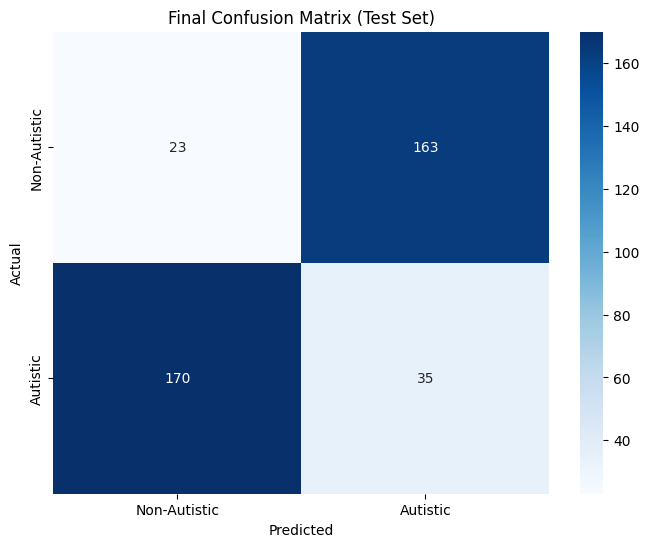


--- Final Classification Report ---
              precision    recall  f1-score   support

Non-Autistic       0.12      0.12      0.12       186
    Autistic       0.18      0.17      0.17       205

    accuracy                           0.15       391
   macro avg       0.15      0.15      0.15       391
weighted avg       0.15      0.15      0.15       391



In [14]:
# 2. Re-batch the Test Dataset to a smaller size (8)
# We apply prepare_for_training and then map to the multi-output dictionary structure
test_ds_low_mem = test_ds.unbatch().batch(8).map(prepare_for_training)
test_ds_low_mem = test_ds_low_mem.map(lambda x, y: (x, {'classification_output': y}))

print("Evaluating on Test Dataset with low-memory configuration...")

# 3. Perform Evaluation
evaluation_results = unified_model.evaluate(test_ds_low_mem)
print(f"\nTest Accuracy: {evaluation_results[1]*100:.2f}%")
print(f"Test Precision: {evaluation_results[2]*100:.2f}%")
print(f"Test Recall: {evaluation_results[3]*100:.2f}%")

# 4. Get Predictions for the Confusion Matrix
y_true = []
y_pred = []

print("\nGenerating Confusion Matrix data...")
for images, labels in test_ds_low_mem:
    true_labels = labels['classification_output'].numpy().flatten()
    # We use verbose=0 to keep the console clean
    preds, _ = unified_model.predict(images, verbose=0)
    
    y_true.extend(true_labels)
    y_pred.extend((preds > 0.5).astype(int).flatten())

# 5. Visualize
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Autistic', 'Autistic'], 
            yticklabels=['Non-Autistic', 'Autistic'])
plt.title('Final Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\n--- Final Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Non-Autistic', 'Autistic']))

In [ ]:
# --- 5. The Reliability Loop ---
for train_index, val_index in kfold.split(train_val_paths, train_val_labels):
    print(f"\n--- STARTING FOLD {fold_no} ---")
    
    # Split the paths based on K-Fold indices
    train_paths_fold = train_val_paths[train_index]
    train_labels_fold = train_val_labels[train_index]
    
    val_paths_fold = train_val_paths[val_index]
    val_labels_fold = train_val_labels[val_index]
    
    # --- 1. Define Augmentation Layer (Stage 2 Addition) ---
    data_augmentation_layers = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.03), 
        tf.keras.layers.RandomContrast(0.1),
    ])

    # --- 2. Advanced Preprocessing Function ---
    def process_fold_data(file_path, label, augment=False):
        img = tf.io.read_file(file_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [224, 224])
        img = img / 255.0 

        if augment:
            img = tf.expand_dims(img, 0)
            img = data_augmentation_layers(img, training=True)
            img = tf.squeeze(img, 0)

        target_label = 1.0 - tf.cast(label, tf.float32)
        return img, {
            'classification_output': target_label, 
            'asd_feature_vector': target_label
        }

    # --- 3. Build the Datasets inside the Loop ---
    train_ds_fold = (tf.data.Dataset.from_tensor_slices((train_paths_fold, train_labels_fold))
                     .shuffle(len(train_paths_fold))
                     .map(lambda x, y: process_fold_data(x, y, augment=True), 
                          num_parallel_calls=tf.data.AUTOTUNE)
                     .batch(BATCH_SIZE)
                     .prefetch(tf.data.AUTOTUNE))

    val_ds_fold = (tf.data.Dataset.from_tensor_slices((val_paths_fold, val_labels_fold))
                   .map(lambda x, y: process_fold_data(x, y, augment=False), 
                        num_parallel_calls=tf.data.AUTOTUNE)
                   .batch(BATCH_SIZE)
                   .prefetch(tf.data.AUTOTUNE))

    print(f"Fold {fold_no} Data Pipelines Ready.")

    # --- 4. Build/Reset Model (Indented properly now) ---
    from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
    from tensorflow.keras.models import Model
    from tensorflow.keras.regularizers import l2
    from deepface import DeepFace

    # A. Load Backbone
    vgg_model_wrapper = DeepFace.build_model("VGG-Face")
    full_vgg_face = vgg_model_wrapper.model 
    backbone_output = full_vgg_face.get_layer("conv2d_14").output
    feature_extractor = Model(inputs=full_vgg_face.input, outputs=backbone_output)
    feature_extractor.trainable = False 

    # B. Attach Head
    inputs = Input(shape=(224, 224, 3), name="face_input")
    x = feature_extractor(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    feature_layer = Dense(256, activation='relu', kernel_regularizer=l2(0.01), name='asd_feature_vector')(x)
    x = Dropout(0.5)(feature_layer)
    prediction = Dense(1, activation='sigmoid', name='classification_output')(x)

    # C. Compile Model
    unified_model = Model(inputs=inputs, outputs=[prediction, feature_layer])
    unified_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss={'classification_output': 'binary_crossentropy', 'asd_feature_vector': None},
        metrics={'classification_output': ['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]}
    )

    # --- 5. Training Phase 1 ---
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
    lr_scheduler = ReduceLROnPlateau(monitor='val_classification_output_loss', factor=0.5, patience=3, verbose=1)
    early_stop = EarlyStopping(monitor='val_classification_output_loss', patience=8, restore_best_weights=True)
    checkpoint = ModelCheckpoint(f'fold_{fold_no}_best.h5', monitor='val_classification_output_accuracy', save_best_only=True)

    history_p1 = unified_model.fit(train_ds_fold, validation_data=val_ds_fold, epochs=30, callbacks=[lr_scheduler, early_stop, checkpoint])

    # --- 6. Training Phase 2 (Fine-Tuning) ---
    feature_extractor.trainable = True
    for layer in feature_extractor.layers[:-12]:
        layer.trainable = False

    unified_model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-6, weight_decay=1e-4),
        loss={'classification_output': 'binary_crossentropy'},
        metrics={'classification_output': ['accuracy']}
    )

    history_p2 = unified_model.fit(train_ds_fold, validation_data=val_ds_fold, epochs=15, callbacks=[lr_scheduler, early_stop, checkpoint])

    # --- 7. Save Results ---
    final_val_acc = max(history_p2.history['val_accuracy'])
    fold_results.append(final_val_acc)
    print(f"Fold {fold_no} Completed. Accuracy: {final_val_acc:.4f}")
    
    # --- 8. GPU Memory Management ---
    del unified_model        
    tf.keras.backend.clear_session()  
    import gc
    gc.collect()            
    
    fold_no += 1